In [2]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [3]:
from ucimlrepo import fetch_ucirepo

Wine = fetch_ucirepo(id=109)

# can also do 
'''
from sklearn.datasets import load_wine
Wine = load_wine()

x = Wine.data
y = Wine.target

# or also

X, y = load_wine(return_X_y=True)
print(x)
'''
from ucimlrepo import fetch_ucirepo

Wine = fetch_ucirepo(id=109)
original_df = Wine.data.original
X = Wine.data.features
y = Wine.data.targets
# print(type(y))
# print(x.info())
# print(y.shape)
print(X.head())


   Alcohol  Malicacid   Ash  Alcalinity_of_ash  Magnesium  Total_phenols  \
0    14.23       1.71  2.43               15.6        127           2.80   
1    13.20       1.78  2.14               11.2        100           2.65   
2    13.16       2.36  2.67               18.6        101           2.80   
3    14.37       1.95  2.50               16.8        113           3.85   
4    13.24       2.59  2.87               21.0        118           2.80   

   Flavanoids  Nonflavanoid_phenols  Proanthocyanins  Color_intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   0D280_0D315_of_diluted_wines  Proline  
0                        

[[23  0  0]
 [ 0 26  0]
 [ 0  0  5]]


<Figure size 2000x600 with 0 Axes>

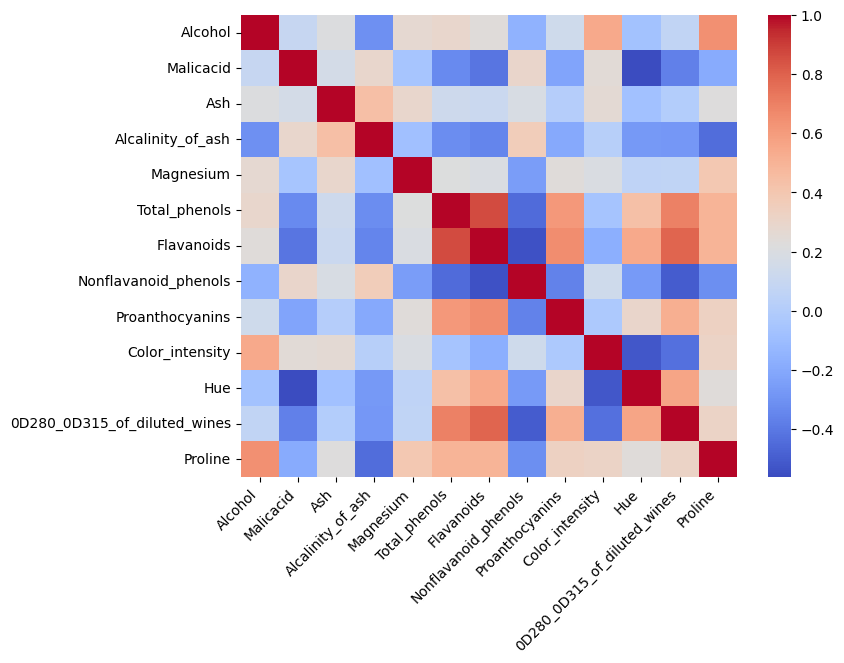

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 598)

# scaler = StandardScaler()
# scaler.fit_transform(X_train)
# scaler.transform(X_test)
print(confusion_matrix(y_test, y_test))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
corr = X.corr()


plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm",
            xticklabels=corr.columns, yticklabels=corr.columns, annot_kws={"size": 8})

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()


In [5]:
NB = GaussianNB()
NB.fit(X_train, y_train.values.ravel())
NB_y_pred = NB.predict(X_test)
print(confusion_matrix(y_test, NB_y_pred))
print(f"Accuracy score: {accuracy_score(y_test, NB_y_pred)}")
print("Gaussian NB misclassifies 2 of the samples")

[[22  1  0]
 [ 0 25  1]
 [ 0  0  5]]
Accuracy score: 0.9629629629629629
Gaussian NB misclassifies 2 of the samples


In [6]:
LDA = LinearDiscriminantAnalysis(store_covariance=True)
LDA.fit(X_train, y_train.values.ravel())
LDA_y_pred = LDA.predict(X_test)
# print(LDA.covariance_)
print(confusion_matrix(y_test, LDA_y_pred))
print(f"Accuracy score: {accuracy_score(y_test, LDA_y_pred)}")

print("LDA misclassifies 2 of the samples")

[[23  0  0]
 [ 0 25  1]
 [ 0  1  4]]
Accuracy score: 0.9629629629629629
LDA misclassifies 2 of the samples


In [7]:
QDA = QuadraticDiscriminantAnalysis()
QDA.fit(X_train, y_train.values.ravel())
QDA_y_pred = QDA.predict(X_test)
print(confusion_matrix(y_test, QDA_y_pred))
print(f"Accuracy score: {accuracy_score(y_test, QDA_y_pred)}")

print("QDA only misclassifies a single sample -- the least of all the models")

[[23  0  0]
 [ 1 25  0]
 [ 0  0  5]]
Accuracy score: 0.9814814814814815
QDA only misclassifies a single sample -- the least of all the models


In [8]:
# LogReg = LogisticRegression(random_state = 598, max_iter=5000, penalty = 'l2', solver = 'newton-cholesky')
# Tried all configs for solvers and penalties -- the default configuration has the best performance
# Logistic Regression is a Gradient-climbng measure, so it requires a random initializaton and a number of iteratiions for gradient-descent.
# LogReg = LogisticRegression(random_state = 598, max_iter=5000)
LogReg = LogisticRegression(random_state = 598, max_iter=5000)
LogReg.fit(X_train, y_train.values.ravel())
LogReg_y_pred = LogReg.predict(X_test)
print(confusion_matrix(y_test, LogReg_y_pred))
print(f"Accuracy score: {accuracy_score(y_test, LogReg_y_pred)}")

print("Multinomial Logistic Regression misclassifies 3 samples -- the most of all the models")


[[23  0  0]
 [ 1 24  1]
 [ 0  1  4]]
Accuracy score: 0.9444444444444444
Multinomial Logistic Regression misclassifies 3 samples -- the most of all the models


I'm assuming, since there isn't a label to the classification, that the data simply consists of 3 varietals of wines, and that the function of the dataset is to classify, based on the features of each sample, which varietal the sample belongs to. Quadratic Discriminant Analysis accounts for a unique covariance between all features, which may risk overfitting on training data, but performs well in this instance. This is likely because some of the classes have much more correlation than other classes (For example, Total_phenols and Flavanoids(which are phenols) are more correlated Flavanoids and Color_intensity).

Problem 2

In [9]:

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier



In [10]:
train = pd.read_csv("pendigits.tra", header = None)
test = pd.read_csv("pendigits.tes", header = None)

X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]
X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [11]:
svc = SVC(kernel = 'rbf', random_state = 598)
svc.fit(X_train, y_train)
svc_y_pred = svc.predict(X_test)
print(confusion_matrix(y_test, svc_y_pred))
print(f"Accuracy score: {accuracy_score(y_test, svc_y_pred)}")


[[353   0   0   0   0   0   0   0  10   0]
 [  0 350  13   0   1   0   0   0   0   0]
 [  0   2 362   0   0   0   0   0   0   0]
 [  0   1   0 333   0   0   0   0   0   2]
 [  0   0   0   0 359   4   1   0   0   0]
 [  0   0   0   4   0 329   0   0   0   2]
 [  0   0   0   0   0   0 336   0   0   0]
 [  0  12   1   0   0   0   0 347   0   4]
 [  0   0   0   0   0   1   0   0 335   0]
 [  0   2   0   0   0   0   0   3   1 330]]
Accuracy score: 0.9817038307604345


In [12]:
decision_tree = DecisionTreeClassifier(random_state=598)

path = decision_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[::5] # only chooses every 5 values, just to cut down on training time


param_grid = {
    'max_depth': [5, 7, 9, 11, 13],
    'min_samples_leaf': [1, 3, 5],
    'ccp_alpha': ccp_alphas
}


tree_cv = GridSearchCV(decision_tree,
                      param_grid,
                      cv=5,
                      scoring='neg_mean_squared_error',
                      n_jobs=-1,
                      verbose=True)
tree_cv.fit(X_train, y_train.values.ravel())



Fitting 5 folds for each of 585 candidates, totalling 2925 fits


,estimator,DecisionTreeC...dom_state=598)
,param_grid,"{'ccp_alpha': array([0. ..., 0.07218135]), 'max_depth': [5, 7, ...], 'min_samples_leaf': [1, 3, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [13]:
# print(y_test)
tree_y_pred = tree_cv.predict(X_test)
# print(tree_y_pred)
print(confusion_matrix(y_test, tree_y_pred))
print(f"Accuracy score: {accuracy_score(y_test, tree_y_pred)}")


[[347   0   0   0   0   0   1   1  14   0]
 [  0 314  44   2   1   1   0   2   0   0]
 [  0  10 348   0   0   2   1   2   1   0]
 [  1  11   2 314   0   4   0   3   0   1]
 [  0   1   0   1 354   0   6   0   0   2]
 [  0   3   1  26   2 282   0   4   2  15]
 [  4   0   1   0   7   4 318   1   1   0]
 [  0  37   4   7   0   0   0 311   4   1]
 [  8   1   0   1   1   4   2   1 318   0]
 [  1   8   0   4   1   5   1   2   3 311]]
Accuracy score: 0.9196683819325329
